In [ ]:
from pathlib import Path
import pandas as pd

DATA_PATH = Path("raw/combinenew.csv")

df = pd.read_csv(DATA_PATH, low_memory=False)
df.columns = df.columns.str.strip()
df.replace([float("inf"), float("-inf")], pd.NA, inplace=True)

print(f"Dataset shape: {df.shape}")
display(df.head())


In [9]:
# Cell 1 — Imports and configuration
from pathlib import Path
import re
import json
import joblib
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import ConfusionMatrixDisplay, classification_report
from sklearn.model_selection import train_test_split

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (12, 6)

DATA_PATH = Path("raw/combinenew.csv")
MODEL_PATH = Path("model/random_forest.pkl")  # optional

df = pd.read_csv(DATA_PATH)
df.columns = df.columns.str.strip()

print(f"Dataset shape: {df.shape}")
display(df.head())

C:\Users\sicmu\AppData\Local\Temp\ipykernel_3636\130522362.py:21: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(DATA_PATH)


Dataset shape: (2830744, 79)


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3.0,2.0,0.0,12.0,0.0,6.0,6.0,6.0,0.0,...,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
1,55054,109.0,1.0,1.0,6.0,6.0,6.0,6.0,6.0,0.0,...,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
2,55055,52.0,1.0,1.0,6.0,6.0,6.0,6.0,6.0,0.0,...,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
3,46236,34.0,1.0,1.0,6.0,6.0,6.0,6.0,6.0,0.0,...,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
4,54863,3.0,2.0,0.0,12.0,0.0,6.0,6.0,6.0,0.0,...,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN


In [10]:
# Cell 2 — Find important columns automatically
def find_column(columns, candidates):
    normalized = {
        re.sub(r"[^a-z0-9]", "", col.lower()): col
        for col in columns
    }

    for candidate in candidates:
        key = re.sub(r"[^a-z0-9]", "", candidate.lower())
        if key in normalized:
            return normalized[key]

    return None

LABEL_COL = find_column(df.columns, [
    "Label", "Attack", "Attack Type", "Class", "Category"
])

PROTOCOL_COL = find_column(df.columns, [
    "Protocol", "Protocol Type"
])

DST_PORT_COL = find_column(df.columns, [
    "Destination Port", "Dst Port", "Dest Port", "Dport"
])

TIME_COL = find_column(df.columns, [
    "Timestamp", "Time", "Date Time", "Flow Start Time"
])

print("Label column:", LABEL_COL)
print("Protocol column:", PROTOCOL_COL)
print("Destination port column:", DST_PORT_COL)
print("Time column:", TIME_COL)

if LABEL_COL is None:
    raise ValueError("Could not find the attack-label column. Set LABEL_COL manually.")

Label column: Label
Protocol column: None
Destination port column: Destination Port
Time column: None


In [11]:
# Cell 3 — Dataset health and label normalization
df[LABEL_COL] = (
    df[LABEL_COL]
    .astype(str)
    .str.strip()
    .str.replace(r"\s+", " ", regex=True)
)

print("Missing values:")
display(df.isna().sum().sort_values(ascending=False).head(20))

print("\nAttack labels:")
display(df[LABEL_COL].value_counts().rename_axis("attack").reset_index(name="flows"))

Missing values:


Flow Bytes/s              1359
Max Packet Length            1
Fwd Avg Bulk Rate            1
Fwd Avg Bytes/Bulk           1
Fwd Header Length.1          1
Avg Bwd Segment Size         1
Avg Fwd Segment Size         1
Average Packet Size          1
Down/Up Ratio                1
ECE Flag Count               1
CWE Flag Count               1
URG Flag Count               1
ACK Flag Count               1
PSH Flag Count               1
RST Flag Count               1
SYN Flag Count               1
FIN Flag Count               1
Packet Length Variance       1
Packet Length Std            1
Fwd Avg Packets/Bulk         1
dtype: int64


Attack labels:


,attack,flows
0,BENIGN,2273097
1,DoS Hulk,231073
2,PortScan,158930
3,DDoS,128027
4,DoS GoldenEye,10293
5,FTP-Patator,7938
6,SSH-Patator,5897
7,DoS slowloris,5796
8,DoS Slowhttptest,5499
9,Bot,1966


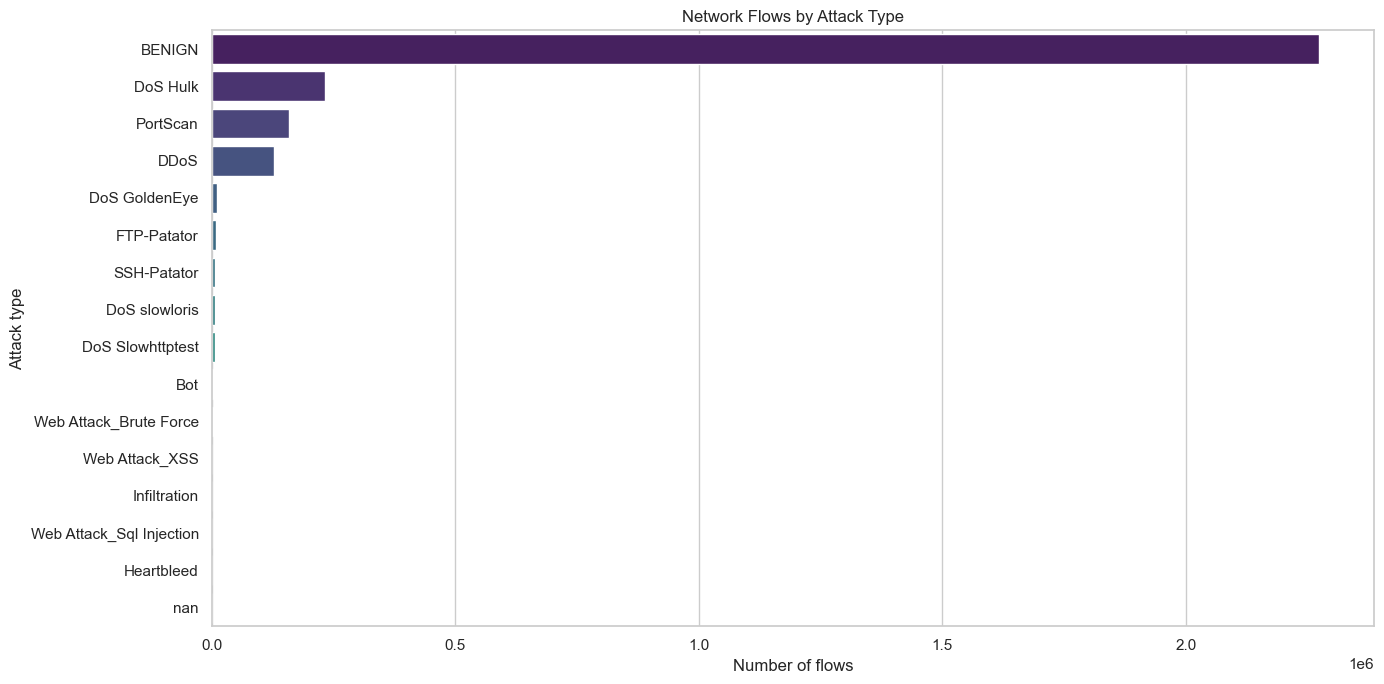

,flows,percentage
Label,,
BENIGN,2273097,80.30
DoS Hulk,231073,8.16
PortScan,158930,5.61
DDoS,128027,4.52
DoS GoldenEye,10293,0.36
FTP-Patator,7938,0.28
SSH-Patator,5897,0.21
DoS slowloris,5796,0.20
DoS Slowhttptest,5499,0.19


In [12]:
# Cell 4 — Which attacks are most common?
attack_counts = df[LABEL_COL].value_counts()

plt.figure(figsize=(14, 7))
sns.barplot(
    x=attack_counts.values,
    y=attack_counts.index,
    hue=attack_counts.index,
    legend=False,
    palette="viridis"
)
plt.title("Network Flows by Attack Type")
plt.xlabel("Number of flows")
plt.ylabel("Attack type")
plt.tight_layout()
plt.show()

display(
    pd.DataFrame({
        "flows": attack_counts,
        "percentage": (attack_counts / len(df) * 100).round(2)
    })
)

In [ ]:
# Cell 5 — Which destination ports are targeted?
if DST_PORT_COL:
    df[DST_PORT_COL] = pd.to_numeric(df[DST_PORT_COL], errors="coerce")

    top_ports = (
        df.dropna(subset=[DST_PORT_COL])
        .groupby([LABEL_COL, DST_PORT_COL])
        .size()
        .reset_index(name="flows")
        .sort_values([LABEL_COL, "flows"], ascending=[True, False])
        .groupby(LABEL_COL)
        .head(10)
    )

    display(top_ports)

    top_overall_ports = df[DST_PORT_COL].value_counts().head(20)

    plt.figure(figsize=(14, 7))
    sns.barplot(
        x=top_overall_ports.values,
        y=top_overall_ports.index.astype(str),
        hue=top_overall_ports.index.astype(str),
        legend=False,
        palette="magma"
    )
    plt.title("Top Targeted Destination Ports")
    plt.xlabel("Number of flows")
    plt.ylabel("Destination port")
    plt.tight_layout()
    plt.show()
else:
    print("No destination-port column found.")

In [13]:
# Cell 6 — Protocol distribution by attack
if PROTOCOL_COL:
    protocol_by_attack = pd.crosstab(
        df[LABEL_COL],
        df[PROTOCOL_COL],
        normalize="index"
    ) * 100

    display(protocol_by_attack.round(2))

    protocol_by_attack.plot(
        kind="bar",
        stacked=True,
        figsize=(15, 7),
        colormap="tab20"
    )
    plt.title("Protocol Distribution by Attack Type")
    plt.xlabel("Attack type")
    plt.ylabel("Percentage of flows")
    plt.legend(title="Protocol", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()
else:
    print("No protocol column found.")

No protocol column found.


In [14]:
# Cell 7 — How traffic changes over time
if TIME_COL:
    df["_timestamp"] = pd.to_datetime(df[TIME_COL], errors="coerce")

    time_data = (
        df.dropna(subset=["_timestamp"])
        .set_index("_timestamp")
        .groupby([pd.Grouper(freq="h"), LABEL_COL])
        .size()
        .reset_index(name="flows")
    )

    plt.figure(figsize=(16, 7))
    sns.lineplot(
        data=time_data,
        x="_timestamp",
        y="flows",
        hue=LABEL_COL,
        linewidth=1.5
    )
    plt.title("Traffic Volume Over Time by Attack Type")
    plt.xlabel("Time")
    plt.ylabel("Flows per hour")
    plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()
else:
    print("No timestamp column found; skipping time analysis.")

No timestamp column found; skipping time analysis.


Features with the strongest difference between attack groups:


Flow Duration             1.174509e+15
Fwd IAT Total             1.168297e+15
Bwd IAT Total             1.083093e+15
Idle Max                  3.575679e+14
Flow IAT Max              3.530991e+14
Fwd IAT Max               3.491052e+14
Idle Mean                 2.822778e+14
Idle Min                  2.457997e+14
Bwd IAT Max               1.973916e+14
Bwd IAT Mean              8.407123e+13
Fwd IAT Mean              5.412433e+13
Bwd IAT Min               5.261523e+13
Fwd IAT Std               4.675232e+13
Fwd IAT Min               4.091142e+13
Flow IAT Std              3.876622e+13
Bwd IAT Std               2.086875e+13
Flow IAT Mean             1.966954e+13
Idle Std                  9.772862e+12
Flow IAT Min              8.453955e+12
Packet Length Variance    3.547478e+12
Name: between_attack_variance, dtype: float64

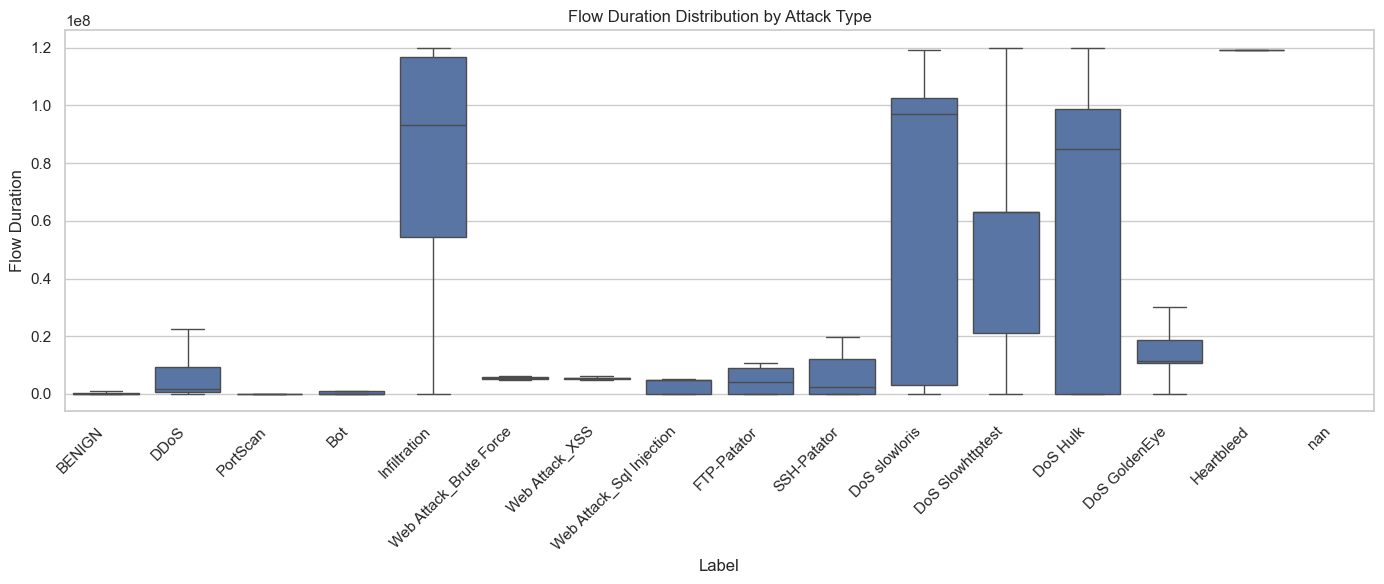

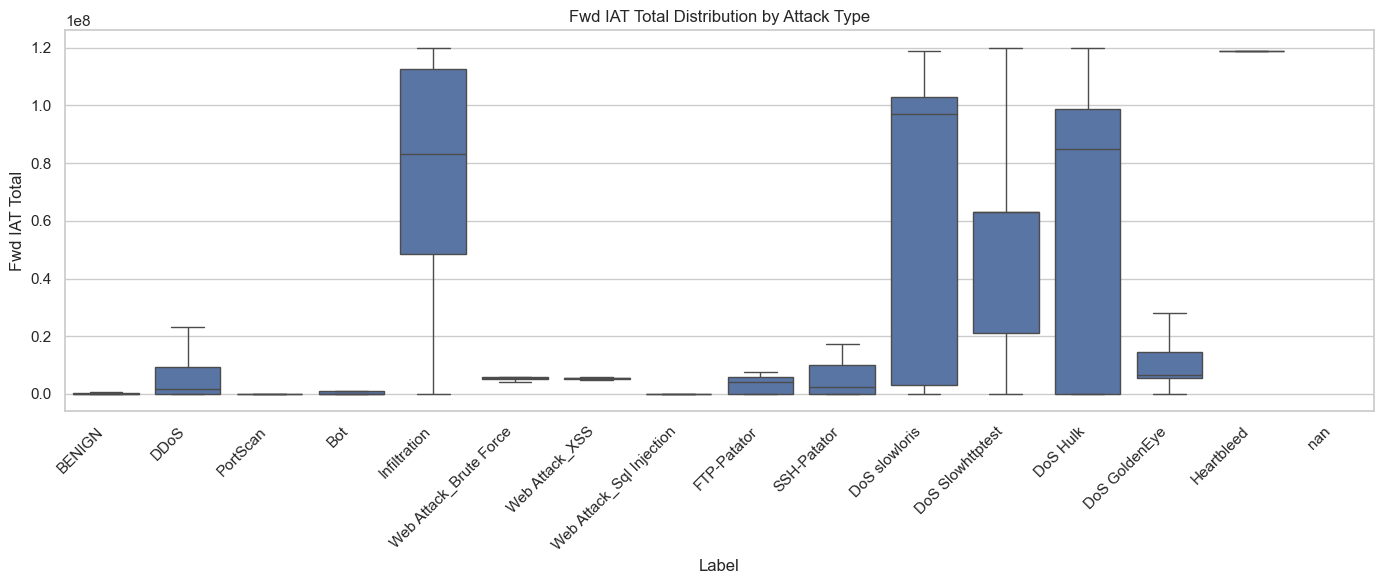

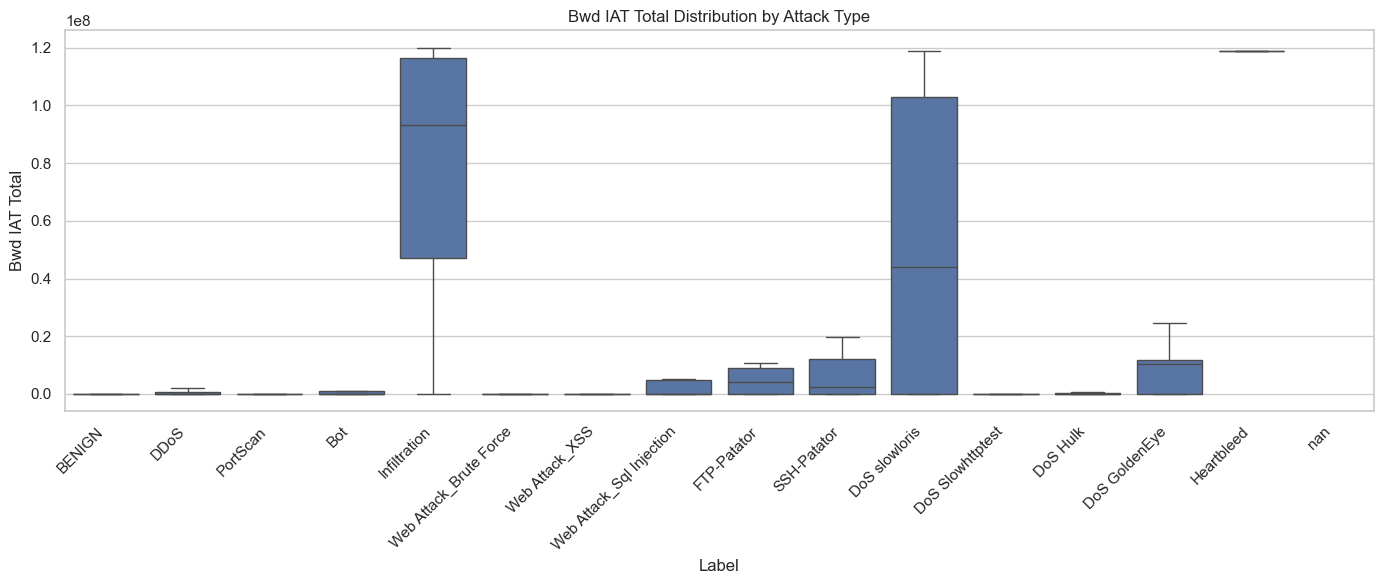

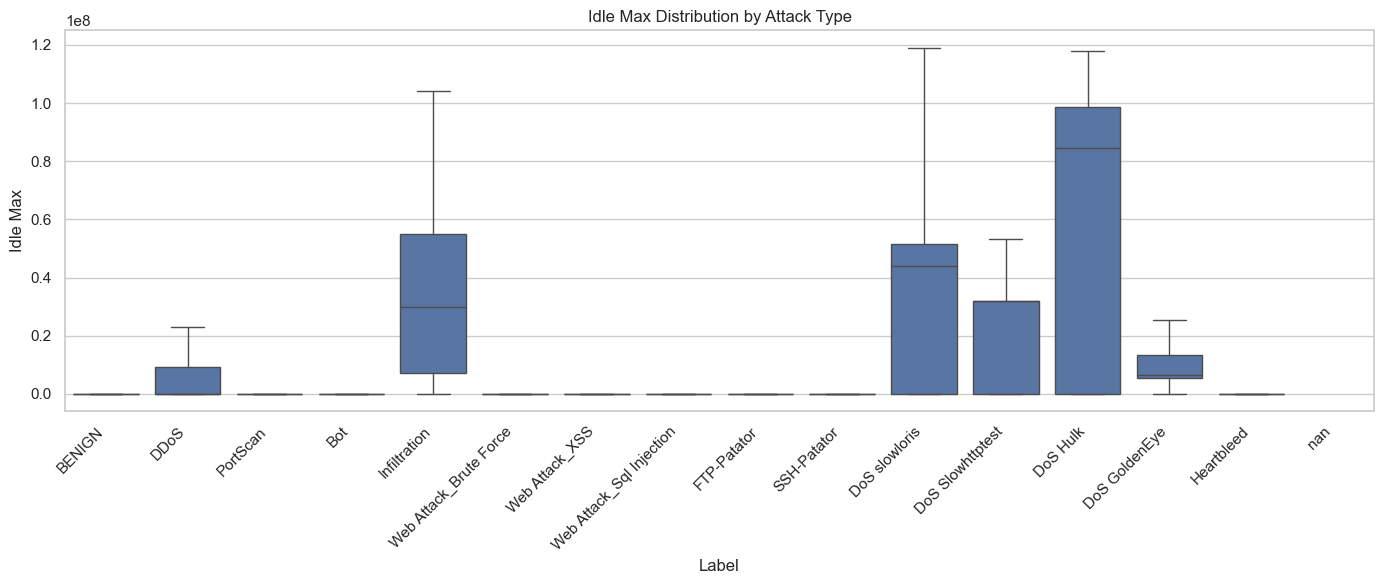

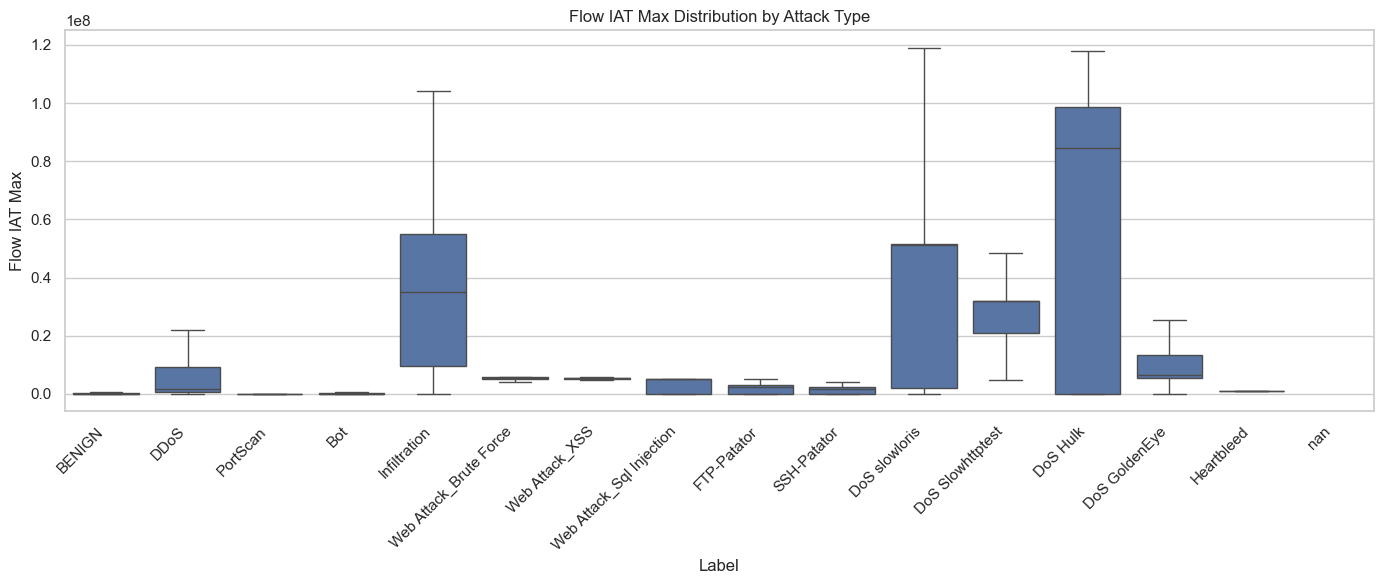

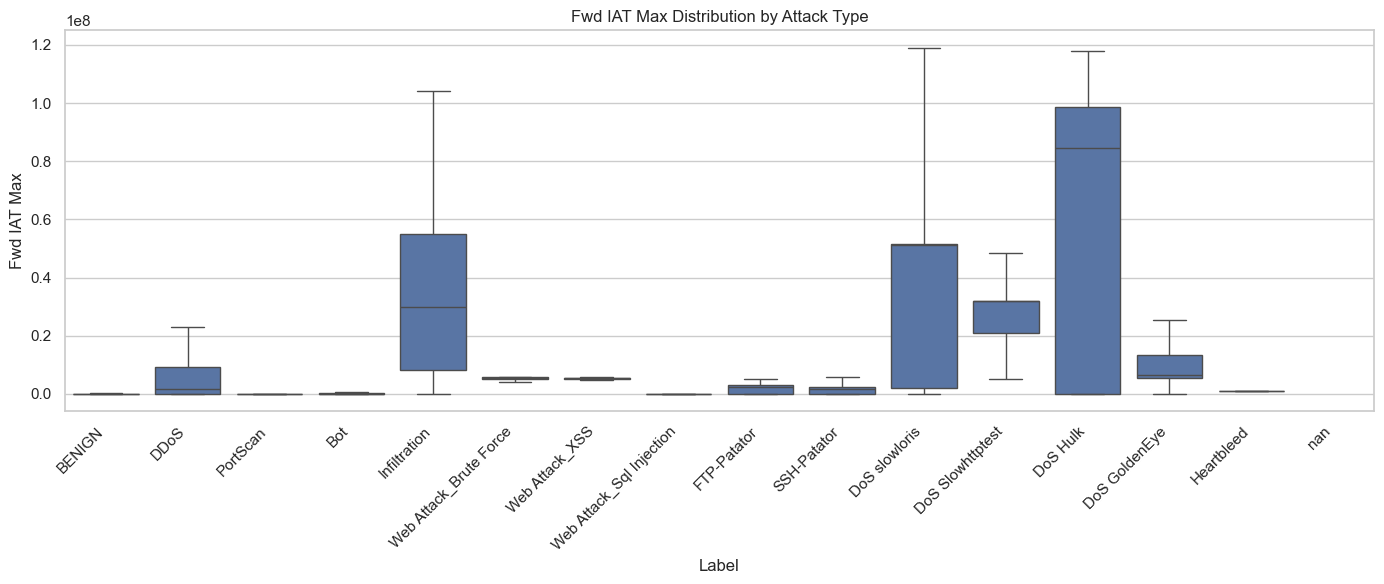

In [15]:
# Cell 8 — Features that distinguish attacks
# Uses numeric fields only and compares attack-group averages.
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

# Exclude ports from this particular comparison if desired:
# numeric_cols = [c for c in numeric_cols if c != DST_PORT_COL]

feature_separation = (
    df.groupby(LABEL_COL)[numeric_cols]
    .mean()
    .T
)

# Rank features by variation in average values across attack groups.
feature_rank = feature_separation.var(axis=1).sort_values(ascending=False)

print("Features with the strongest difference between attack groups:")
display(feature_rank.head(20).rename("between_attack_variance"))

top_features = feature_rank.head(12).index.tolist()

for feature in top_features[:6]:
    plt.figure(figsize=(14, 6))
    sns.boxplot(
        data=df,
        x=LABEL_COL,
        y=feature,
        showfliers=False
    )
    plt.title(f"{feature} Distribution by Attack Type")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

In [17]:
# Cell 9 — Random Forest feature importance
# Loads an existing saved model if available.
# If no model exists, it trains a temporary analysis model.

drop_columns = [LABEL_COL, "_timestamp", TIME_COL]
X = df.drop(columns=[c for c in drop_columns if c in df.columns], errors="ignore")

# Keep numeric features for this EDA model.
X = X.select_dtypes(include=np.number).replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.median())

y = df[LABEL_COL]

if MODEL_PATH.exists():
    rf = joblib.load(MODEL_PATH)
    print(f"Loaded model from {MODEL_PATH}")
else:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

    rf = RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1,
        class_weight="balanced_subsample"
    )
    rf.fit(X_train, y_train)
    print("Trained a temporary EDA Random Forest model.")

if hasattr(rf, "feature_importances_"):
    model_features = list(getattr(rf, "feature_names_in_", X.columns))

    importance_df = pd.DataFrame({
        "feature": model_features,
        "importance": rf.feature_importances_
    }).sort_values("importance", ascending=False)

    display(importance_df.head(20))

    plt.figure(figsize=(12, 8))
    sns.barplot(
        data=importance_df.head(20),
        x="importance",
        y="feature",
        hue="feature",
        legend=False,
        palette="crest"
    )
    plt.title("Top 20 Features for Attack Detection")
    plt.tight_layout()
    plt.show()

ValueError: The least populated class in y has only 1 member, which is too few. The minimum number of groups for any class cannot be less than 2.

In [16]:
# Cell 10 — Which attacks are difficult to detect?
# Only runs when the temporary EDA model was trained above.
if "X_test" in globals():
    y_pred = rf.predict(X_test)

    print(classification_report(y_test, y_pred, zero_division=0))

    fig, ax = plt.subplots(figsize=(14, 12))
    ConfusionMatrixDisplay.from_predictions(
        y_test,
        y_pred,
        xticks_rotation=45,
        cmap="Blues",
        normalize="true",
        ax=ax,
        colorbar=False
    )
    plt.title("Normalized Confusion Matrix — Hard-to-Detect Attack Classes")
    plt.tight_layout()
    plt.show()

    report = pd.DataFrame(
        classification_report(
            y_test, y_pred, output_dict=True, zero_division=0
        )
    ).T

    hard_attacks = (
        report.drop(index=["accuracy", "macro avg", "weighted avg"], errors="ignore")
        .sort_values("recall")
    )

    print("Lowest recall = attacks the model misses most often:")
    display(hard_attacks[["precision", "recall", "f1-score", "support"]].head(10))
else:
    print("Train the temporary model above to generate a confusion matrix.")

Train the temporary model above to generate a confusion matrix.


In [ ]:
# Cell 11 — Export EDA findings for the project report
summary = {
    "dataset_rows": int(len(df)),
    "dataset_columns": int(len(df.columns)),
    "label_column": LABEL_COL,
    "protocol_column": PROTOCOL_COL,
    "destination_port_column": DST_PORT_COL,
    "timestamp_column": TIME_COL,
    "most_common_attacks": attack_counts.head(10).to_dict(),
    "top_discriminating_features": feature_rank.head(15).to_dict()
}

Path("reports").mkdir(exist_ok=True)

with open("reports/security_eda_summary.json", "w") as file:
    json.dump(summary, file, indent=2, default=str)

print("Saved: reports/security_eda_summary.json")